# Imports

### Solving moabb dependency problem

In [1]:
import moabb.datasets
try:
    from moabb.datasets import BNCI2014_001
    moabb.datasets.BNCI2014001 = BNCI2014_001
except ImportError:
    pass

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import gc
import os

from sklearn.metrics import balanced_accuracy_score,confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from skorch.callbacks import LRScheduler
from skorch.callbacks import EarlyStopping
from skorch.helper import predefined_split
from skorch.dataset import ValidSplit

import mne
from braindecode import EEGClassifier
from braindecode.datasets import BaseConcatDataset, BaseDataset
from braindecode.models import EEGNet
from braindecode.util import set_random_seeds
from braindecode.datautil import load_concat_dataset

import torch

# Loading Data

In [4]:
windows_dataset = load_concat_dataset('preprocessing/eegnet_ner_processed', preload=True)
splitted = windows_dataset.split("subject")
subjects_list = list(splitted.keys())

Opening raw data file preprocessing\eegnet_ner_processed\0\0-raw.fif...
Isotrak not found
    Range : 0 ... 42239 =      0.000 ...   659.984 secs
Ready.
Reading 0 ... 42239  =      0.000 ...   659.984 secs...
Opening raw data file preprocessing\eegnet_ner_processed\1\1-raw.fif...
Isotrak not found
    Range : 0 ... 40959 =      0.000 ...   639.984 secs
Ready.
Reading 0 ... 40959  =      0.000 ...   639.984 secs...
Opening raw data file preprocessing\eegnet_ner_processed\2\2-raw.fif...
Isotrak not found
    Range : 0 ... 40639 =      0.000 ...   634.984 secs
Ready.
Reading 0 ... 40639  =      0.000 ...   634.984 secs...
Opening raw data file preprocessing\eegnet_ner_processed\3\3-raw.fif...
Isotrak not found
    Range : 0 ... 40959 =      0.000 ...   639.984 secs
Ready.
Reading 0 ... 40959  =      0.000 ...   639.984 secs...
Opening raw data file preprocessing\eegnet_ner_processed\4\4-raw.fif...
Isotrak not found
    Range : 0 ... 62719 =      0.000 ...   979.984 secs
Ready.
Reading 0 .

# Model

### CUDA

In [5]:
cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 42
set_random_seeds(seed=seed, cuda=cuda)


n_classes = 2
classes = list(range(n_classes))
# Extract number of chans and time steps from dataset
n_channels = windows_dataset[0][0].shape[0]
n_times = windows_dataset[0][0].shape[1]

c:\Users\oskik\anaconda3\envs\cm\lib\site-packages\braindecode\util.py:52: UserWarning: torch.backends.cudnn.benchmark was set to True which may results in lack of reproducibility. In some cases to ensure reproducibility you may need to set torch.backends.cudnn.benchmark to False.
  warn(


### EEGNet

In [42]:
model = EEGNet(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
    drop_prob=0.4
)

print(model)

if cuda:
    model.cuda()

Layer (type (var_name):depth-idx)                            Input Shape               Output Shape              Param #                   Kernel Shape
EEGNet (EEGNet)                                              [1, 56, 56]               [1, 2]                    --                        --
├─Ensure4d (ensuredims): 1-1                                 [1, 56, 56]               [1, 56, 56, 1]            --                        --
├─Rearrange (dimshuffle): 1-2                                [1, 56, 56, 1]            [1, 1, 56, 56]            --                        --
├─Conv2d (conv_temporal): 1-3                                [1, 1, 56, 56]            [1, 8, 56, 57]            512                       [1, 64]
├─BatchNorm2d (bnorm_temporal): 1-4                          [1, 8, 56, 57]            [1, 8, 56, 57]            16                        --
├─ParametrizedConv2dWithConstraint (conv_spatial): 1-5       [1, 8, 56, 57]            [1, 16, 1, 57]            --                  

### Classifier

In [43]:
lr = 0.0005
batch_size = 64
n_epochs = 250
train_percent = 0.8
train_valid_percent = 0.8

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    optimizer__lr=lr,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        "balanced_accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs
)


In [44]:
early_stopping = EarlyStopping(
    monitor='valid_loss',
    patience=20,
    lower_is_better=True,
    load_best=True
)

# Within-subject

In [56]:
results_within = []
learning_histories = {}

for subject in subjects_list:
    print(f"Trening modelu dla pacjenta {subject}...")

    subj_sessions = splitted[subject].split('session')
    session_keys = sorted(subj_sessions.keys(), key=int)

    split_idx = int(len(session_keys) * train_percent)
    train_keys = session_keys[:split_idx]
    test_keys = session_keys[split_idx:]

    train_set = BaseConcatDataset([subj_sessions[k] for k in train_keys])
    test_set = BaseConcatDataset([subj_sessions[k] for k in test_keys])


    # Chronological split of train and validation sets
    train_len = int(len(train_set) * train_valid_percent)
    actual_train_set = torch.utils.data.Subset(train_set, list(range(train_len)))
    valid_set = torch.utils.data.Subset(train_set, list(range(train_len, len(train_set))))

                                                                             
    print(f"Training set: {len(actual_train_set)} epochs, Validation set: {len(valid_set)} epochs")
    print(f"Testing set: {len(test_set)} epochs (Sessions {test_keys[0]}-{test_keys[-1]})")

    y_actual_train = [actual_train_set[i][1] for i in range(len(actual_train_set))] 
    class_counts = np.bincount(y_actual_train)

    w0 = len(y_actual_train) / (2 * class_counts[0]) 
    w1 = len(y_actual_train) / (2 * class_counts[1]) 
    weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

    clf.set_params(
        criterion__weight=weights,
        train_split=predefined_split(valid_set),
        callbacks=[early_stopping],
        optimizer__weight_decay=0.02
    )

    clf.fit(actual_train_set, y=None)   

    learning_histories[subject] = {
        'train_loss': clf.history[:, 'train_loss'],
        'valid_loss': clf.history[:, 'valid_loss']
    }

    y_pred = clf.predict(test_set)
    y_true = [y for _, y, _ in test_set]
    
    for true_val, pred_val in zip(y_true, y_pred):
        results_within.append({'subject': subject, 'y_true': true_val, 'y_pred': pred_val})
    
    # Free memory
    del train_set, actual_train_set, valid_set, test_set, y_actual_train, y_pred, y_true
    gc.collect()

Trening modelu dla pacjenta 2...
Training set: 192 epochs, Validation set: 48 epochs
Testing set: 100 epochs (Sessions 5-5)
Re-initializing criterion because the following parameters were re-set: criterion__weight.
Re-initializing optimizer.
Re-initializing module.
Re-initializing criterion because the following parameters were re-set: weight.
Re-initializing optimizer.
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.7481       0.6458        1.7661  0.1644
      2        0.6896       0.6667        1.5563  0.1435
      3        0.5818       0.6875        1.3606  0.1322
      4        0.5480       0.7500        1.2019  0.1240
      5        0.5215       0.7500        1.0673  0.1180
      6        0.5060       0.7917        0.9492  0.1426
      7        0.4531       0.8125        0.8506  0.1080
      8        0.4474       0.7917        0.7725  0.1100
      9        0.4525       0.7917        0.7086  0.1103


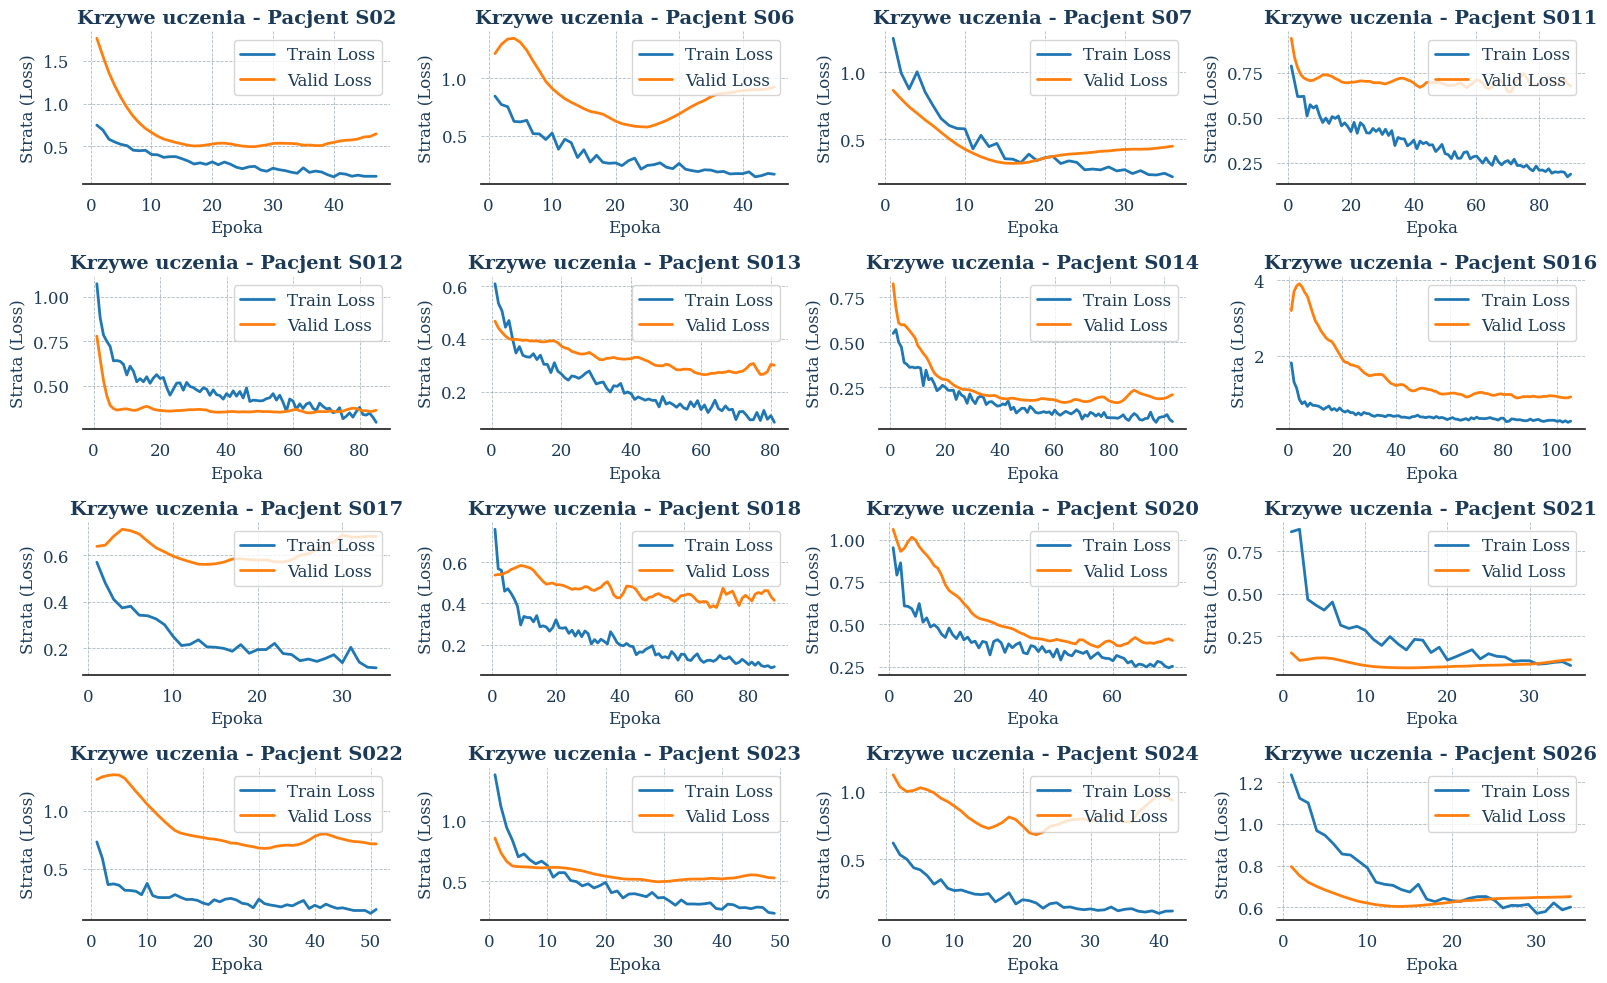

In [57]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for idx, subject in enumerate(subjects_list):
    ax = axes[idx]
    train_loss = learning_histories[subject]['train_loss']
    valid_loss = learning_histories[subject]['valid_loss']
    epochs = range(1, len(train_loss) + 1)
    
    # Rysowanie linii
    ax.plot(epochs, train_loss, label='Train Loss', color='#1f77b4', linewidth=2)
    ax.plot(epochs, valid_loss, label='Valid Loss', color='#ff7f0e', linewidth=2)
    
    # Formatowanie pojedynczego wykresu
    ax.set_title(f'Krzywe uczenia - Pacjent S0{subject}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoka', fontsize=12)
    ax.set_ylabel('Strata (Loss)', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Cross-subject

In [28]:
results_cross = []

for subject in subjects_list:
    print(f"Training cross-subject model for patient {subject}...")

    train_datasets = []

    for sub_id in subjects_list:
        if sub_id == subject:
            test_set = splitted[sub_id]
        else:
            train_datasets.append(splitted[sub_id])

    train_set = BaseConcatDataset(train_datasets)

    # Chronological train valid split
    train_len = int(len(train_set) * 0.8)
    actual_train_set = torch.utils.data.Subset(train_set, range(train_len))
    valid_set = torch.utils.data.Subset(train_set, range(train_len, len(train_set)))

    print(f"Training set: {len(actual_train_set)} epochs, Validation: {len(valid_set)} epochs")
    print(f"Testing set: {len(test_set)} epochs (Patient {subject})")

    y_actual_train = [actual_train_set[i][1] for i in range(len(actual_train_set))] 
    class_counts = np.bincount(y_actual_train) 
    
    w0 = len(y_actual_train) / (2 * class_counts[0]) 
    w1 = len(y_actual_train) / (2 * class_counts[1]) 
    weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

    clf.set_params(
        criterion__weight=weights,
        train_split=ValidSplit(cv=0.2),
        callbacks=[early_stopping],
        optimizer__weight_decay=0.01
    )

    clf.fit(actual_train_set, y=None)  

    y_pred = clf.predict(test_set)
    y_true = [y for _, y, _ in test_set]
    
    for true_val, pred_val in zip(y_true, y_pred):
        results_cross.append({'subject': subject, 'y_true': true_val, 'y_pred': pred_val})

Training cross-subject model for patient 2...
Training set: 4080 epochs, Validation: 1020 epochs
Testing set: 340 epochs (Patient 2)
Re-initializing criterion because the following parameters were re-set: criterion__weight.
Re-initializing optimizer.
Re-initializing module.
Re-initializing criterion because the following parameters were re-set: weight.
Re-initializing optimizer.
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6952       0.7390        0.6618  2.0977
      2        0.6530       0.7328        0.6107  1.8225
      3        0.6397       0.7267        0.5959  1.8081
      4        0.6151       0.7426        0.5862  1.7822
      5        0.6115       0.7377        0.5769  1.8480
      6        0.5921       0.7316        0.5723  1.7960
      7        0.5908       0.7316        0.5657  1.8235
      8        0.5932       0.7316        0.5610  1.8190
      9        0.5779       0.7316        0.5589

# Results

In [58]:
df_results_within = pd.DataFrame(results_within)
df_results_cross = pd.DataFrame(results_cross)

out_dir = "eegnet_ner"
os.makedirs(out_dir, exist_ok=True)
pd.DataFrame(df_results_within).to_csv(f"{out_dir}/results_within.csv", index=False)
pd.DataFrame(df_results_cross).to_csv(f"{out_dir}/results_cross.csv", index=False)

df_within = pd.read_csv(f"{out_dir}/results_within.csv")
df_cross = pd.read_csv(f"{out_dir}/results_cross.csv")

results_table = []

### Metrics function

In [59]:
def calculate_metrics(df, experiment_name):
    results_table = []

    for subject, group in df.groupby('subject'):
        y_true = group['y_true']
        y_pred = group['y_pred']
        
        acc = balanced_accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, pos_label=0)
        precision = precision_score(y_true, y_pred, pos_label=0)
        recall = recall_score(y_true, y_pred, pos_label=0)
        
        results_table.append({
            'Experiment': experiment_name,
            'Patient': f"{subject}",
            'Balanced Accuracy (%)': round(acc, 2),
            'F1-Score (ErrP)': round(f1, 3),
            'Precision (ErrP)': round(precision, 3),
            'Recall (ErrP)': round(recall, 3)
        })
    
    return results_table

In [60]:
results_within = calculate_metrics(df_within, 'Within-Subject')
#results_cross = calculate_metrics(df_cross, 'Cross-Subject')
#combined_results = results_within + results_cross
#df_results = pd.DataFrame(combined_results)
df_results = pd.DataFrame(results_within)

In [61]:
print("--- RESULTS TABLE ---")
print(df_results.to_string(index=False))
pd.DataFrame(df_results.to_csv(f"{out_dir}/results.csv", index=False))

--- RESULTS TABLE ---
    Experiment Patient  Balanced Accuracy (%)  F1-Score (ErrP)  Precision (ErrP)  Recall (ErrP)
Within-Subject       2                  63.23            0.459             0.824          0.318
Within-Subject       6                  67.67            0.400             0.357          0.455
Within-Subject       7                  82.95            0.621             0.529          0.750
Within-Subject      11                  62.18            0.493             0.680          0.386
Within-Subject      12                  62.28            0.559             0.765          0.441
Within-Subject      13                  79.00            0.769             0.854          0.700
Within-Subject      14                  64.00            0.571             0.706          0.480
Within-Subject      16                  63.97            0.557             0.688          0.468
Within-Subject      17                  78.48            0.747             0.738          0.756
Within-Subject    

""


### Confusion matrices

In [62]:
def plot_confusion_matrices(df, experiment_name, filename):
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 10))
    axes = axes.flatten()
    
    subjects_list = sorted(df['subject'].unique())
    
    for i, sub_id in enumerate(subjects_list):
        ax = axes[i]
        
        sub_data = df[df['subject'] == sub_id]
        y_true = sub_data['y_true']
        y_pred = sub_data['y_pred']
        
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ERROR', 'Correct'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        ax.set_title(f"Patient S{int(sub_id):02d}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
    
    plt.suptitle(f"Confusion Matrices - {experiment_name}", fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

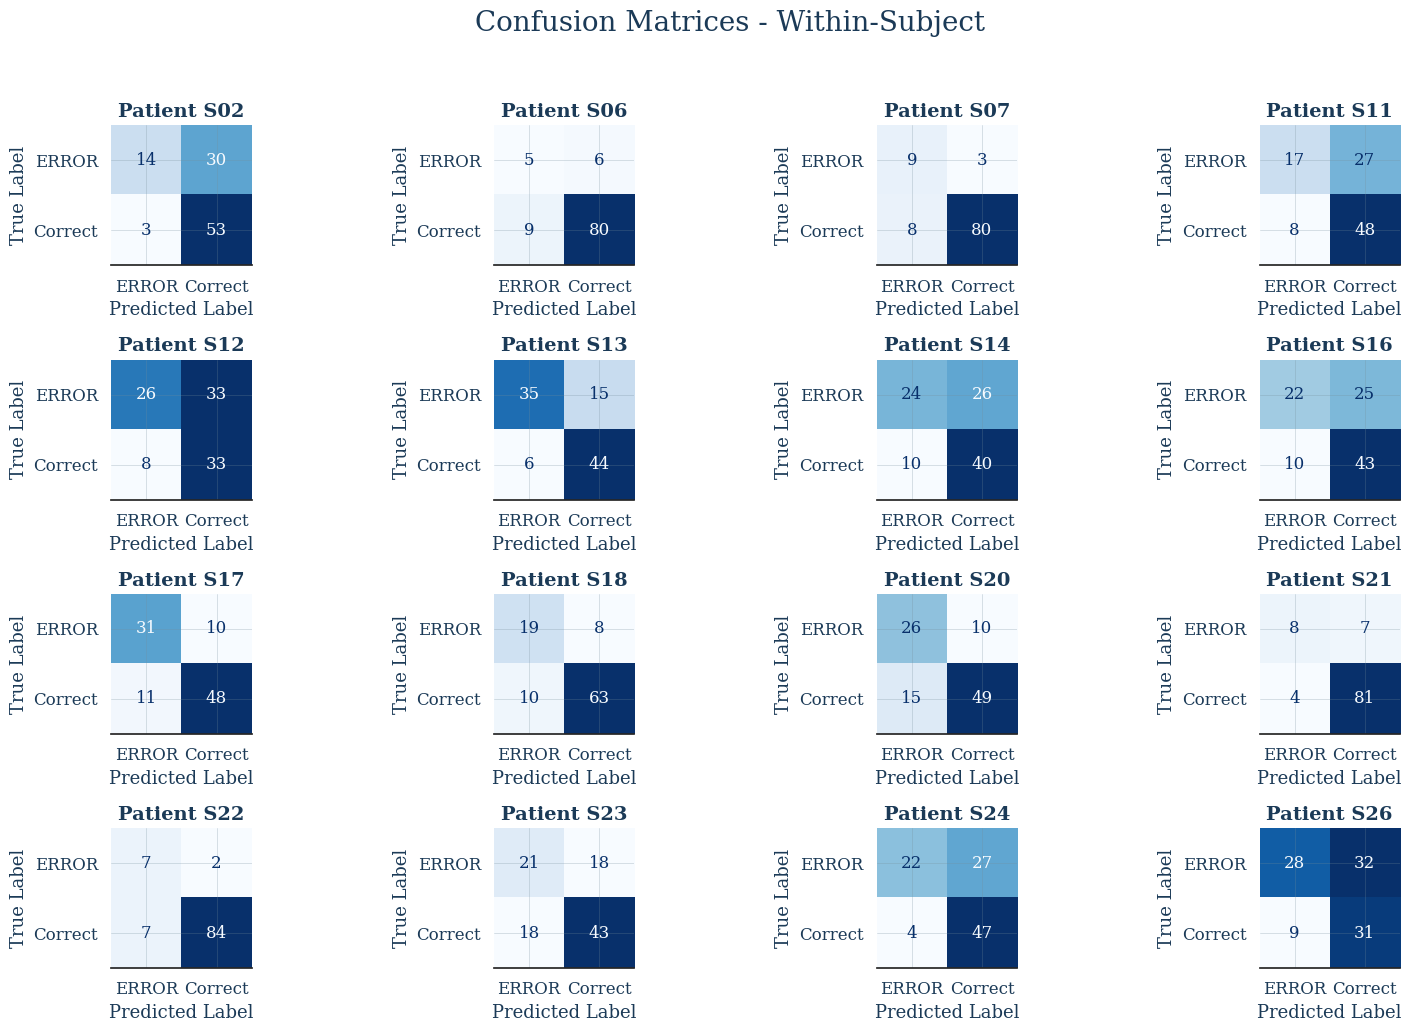

In [63]:
plot_confusion_matrices(df_within, 'Within-Subject', 'EEG_Within_Subject.png')
#plot_confusion_matrices(df_cross, 'Cross-Subject', 'EEG_Cross_Subject.png')

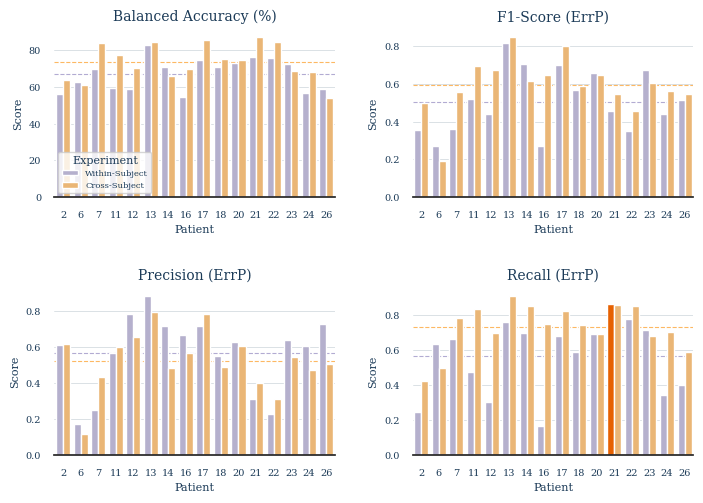

In [35]:
# Create subplots for each metric
df = pd.read_csv("eegnet_ner/results.csv")
metrics = df.columns[2:]
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

target_bar_index = 11
chosen_hex_color = "#e66101"

for i, metric in enumerate(metrics):
    sns.barplot(data=df, x='Patient', y=metric, hue='Experiment', ax=axes[i], palette=['#b2abd2', '#fdb863'])

    mean_within = df[df['Experiment'] == 'Within-Subject'][metric].mean()
    mean_cross = df[df['Experiment'] == 'Cross-Subject'][metric].mean()
    
    # Plot horizontal mean lines
    axes[i].axhline(mean_within, color='#b2abd2', linestyle='--', linewidth=0.8, zorder=0)
    axes[i].axhline(mean_cross, color='#fdb863', linestyle='--', linewidth=0.8, zorder=0)

    if metric == 'Recall (ErrP)':
        patches = axes[i].patches
        if len(patches) > target_bar_index:
            patches[target_bar_index].set_facecolor(chosen_hex_color)

    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xlabel("Patient", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].tick_params(axis='both', which='major', labelsize=7)
    
    if i == 0:
        axes[i].legend(title='Experiment', fontsize=6, title_fontsize=8, loc='lower left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout(pad=0.5, w_pad=2.0, h_pad=2.0)
plt.show()

# MISC

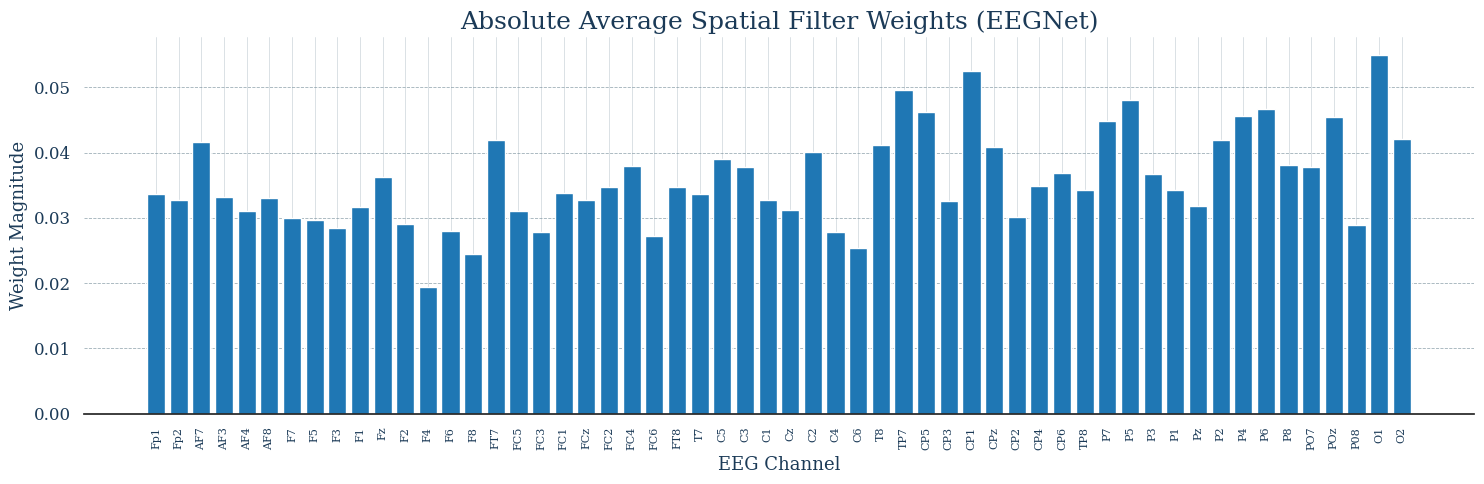

In [36]:
# Extract the spatial convolution weights from the trained EEGNet
# EEGNet layer: conv_spatial (ParametrizedConv2dWithConstraint)
spatial_weights = clf.module_.conv_spatial.weight.detach().cpu().numpy()

# Average the weights across the temporal filters to see overall spatial importance
avg_spatial_weights = np.mean(np.abs(spatial_weights), axis=0).squeeze()

# Plotting the spatial weights as a bar chart (or map if channel coordinates exist)
ch_names = windows_dataset.datasets[0].raw.info['ch_names']

plt.figure(figsize=(15, 5))
plt.bar(range(len(ch_names)), avg_spatial_weights, color='#1f77b4')
plt.xticks(range(len(ch_names)), ch_names, rotation=90, fontsize=8)
plt.title('Absolute Average Spatial Filter Weights (EEGNet)')
plt.xlabel('EEG Channel')
plt.ylabel('Weight Magnitude')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:
# Extract all labels from the dataset
y_labels = [y for _, y, _ in windows_dataset]

# Count the occurrences
count_0 = y_labels.count(0)
count_1 = y_labels.count(1)

print(f"Total count of y=0 (Error): {count_0}")
print(f"Total count of y=1 (Good Feedback): {count_1}")
print(f"Ratio (0:1): {count_0 / count_1:.2f}")

Total count of y=0 (Error): 1590
Total count of y=1 (Good Feedback): 3850
Ratio (0:1): 0.41


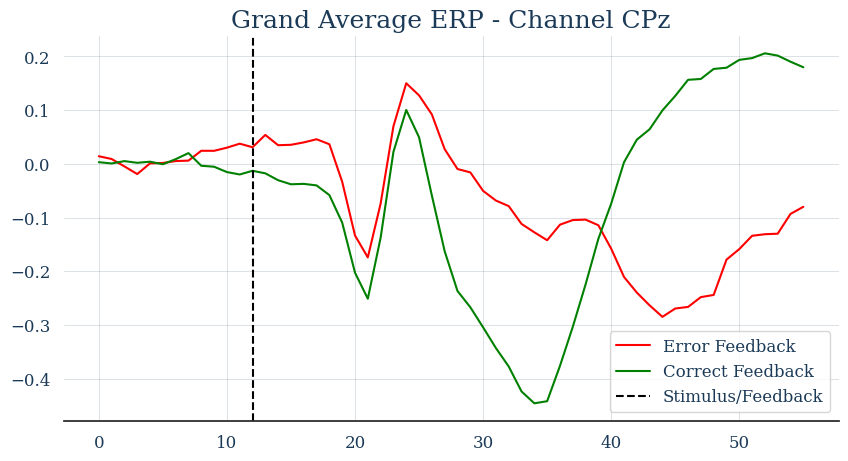

In [41]:
# Extract data for plotting
# Assuming 0 is 'error', 1 is 'good_feedback' (based on your mapping)
error_epochs = []
correct_epochs = []
relevant_channels = ['Fz', 'FCz', 'Cz', 'CPz', 'Pz']

for X, y, _ in windows_dataset:
    if y == 0: # Error
        error_epochs.append(X)
    else:      # Good feedback
        correct_epochs.append(X)

error_epochs = np.array(error_epochs)
correct_epochs = np.array(correct_epochs)

# Average across trials
mean_error = np.mean(error_epochs, axis=0)
mean_correct = np.mean(correct_epochs, axis=0)

# Plot Channel 'FCz' (Change index if FCz is not index 0)
# You can map channel index from: windows_dataset.datasets[0].raw.ch_names
ch_idx = 3 # Replace with the index of 'FCz'
plt.figure(figsize=(10, 5))
plt.plot(mean_error[ch_idx, :], label='Error Feedback', color='red')
plt.plot(mean_correct[ch_idx, :], label='Correct Feedback', color='green')
plt.title(f"Grand Average ERP - Channel {relevant_channels[ch_idx]}")
plt.axvline(x=int(0.2 * 64), color='k', linestyle='--', label='Stimulus/Feedback')
plt.legend()
plt.grid(True)
plt.show()